# Formative Assignment: Advanced Linear Algebra (PCA)
This notebook implements Principal Component Analysis (PCA) from scratch using **numpy only**. The dataset is Africanized: **Malaria in Africa** (World Bank, 54 African countries, 2007-2017).

**Dataset source:** https://www.kaggle.com/datasets/lydia70/malaria-in-africa  
**File used:** DatasetAfricaMalaria.csv

**Group members:** *Elyse Ishimwe, Kethia Kayigire Ngabire*





### Step 1: Load and Standardize the Data
Before applying PCA, we must standardize the dataset. Standardization ensures that all features have a mean of 0 and a standard deviation of 1, which is essential for PCA.
Fill in the code to standardize the dataset.

STRICTLY - Write code that implements standardization based on the image below

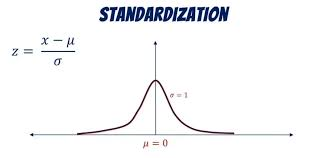


In [1]:
# Step 1: Load and Standardize the data (use of numpy only allowed)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("DatasetAfricaMalaria.csv")
print(df.shape)
df.head()


(594, 27)


,Country Name,Year,Country Code,"Incidence of malaria (per 1,000 population at risk)",Malaria cases reported,Use of insecticide-treated bed nets (% of under-5 population),Children with fever receiving antimalarial drugs (% of children under age 5 with fever),Intermittent preventive treatment (IPT) of malaria in pregnancy (% of pregnant women),People using safely managed drinking water services (% of population),"People using safely managed drinking water services, rural (% of rural population)",...,Urban population growth (annual %),People using at least basic drinking water services (% of population),"People using at least basic drinking water services, rural (% of rural population)","People using at least basic drinking water services, urban (% of urban population)",People using at least basic sanitation services (% of population),"People using at least basic sanitation services, rural (% of rural population)","People using at least basic sanitation services, urban (% of urban population)",latitude,longitude,geometry
0,Algeria,2007,DZA,0.01,26.0,NaN,NaN,NaN,NaN,NaN,...,2.71,91.68,85.83,94.78,85.85,76.94,90.57,28.033886,1.659626,POINT (28.033886 1.659626)
1,Angola,2007,AGO,286.72,1533485.0,18.0,29.8,1.5,NaN,NaN,...,5.01,47.96,23.77,65.83,37.26,14.00,54.44,-11.202692,17.873887,POINT (-11.202692 17.873887)
2,Benin,2007,BEN,480.24,0.0,NaN,NaN,NaN,NaN,NaN,...,4.09,63.78,54.92,76.24,11.80,4.29,22.36,9.307690,2.315834,POINT (9.307689999999999 2.315834)
3,Botswana,2007,BWA,1.03,390.0,NaN,NaN,NaN,NaN,NaN,...,4.80,78.89,57.60,94.35,61.60,39.99,77.30,-22.328474,24.684866,POINT (-22.328474 24.684866)
4,Burkina Faso,2007,BFA,503.80,44246.0,NaN,NaN,NaN,NaN,NaN,...,5.91,52.27,45.13,76.15,15.60,6.38,46.49,12.238333,-1.561593,POINT (12.238333 -1.561593)


In [3]:
print(df.dtypes)

Country Name                                                                                object
Year                                                                                         int64
Country Code                                                                                object
Incidence of malaria (per 1,000 population at risk)                                        float64
Malaria cases reported                                                                     float64
Use of insecticide-treated bed nets (% of under-5 population)                              float64
Children with fever receiving antimalarial drugs (% of children under age 5 with fever)    float64
Intermittent preventive treatment (IPT) of malaria in pregnancy (% of pregnant women)      float64
People using safely managed drinking water services (% of population)                      float64
People using safely managed drinking water services, rural (% of rural population)         float64
People usi

In [4]:
print("\nMissing values per column")
print(df.isnull().sum())


Missing values per column
Country Name                                                                                 0
Year                                                                                         0
Country Code                                                                                 0
Incidence of malaria (per 1,000 population at risk)                                         44
Malaria cases reported                                                                      44
Use of insecticide-treated bed nets (% of under-5 population)                              462
Children with fever receiving antimalarial drugs (% of children under age 5 with fever)    472
Intermittent preventive treatment (IPT) of malaria in pregnancy (% of pregnant women)      488
People using safely managed drinking water services (% of population)                      495
People using safely managed drinking water services, rural (% of rural population)         506
People using safely man

In [5]:
print(" Non-numeric columns")
print(df.select_dtypes(exclude=[np.number]).columns.tolist())

 Non-numeric columns
['Country Name', 'Country Code', 'geometry']


In [6]:

country_labels= df['Country Name'].values
df=df.drop(columns=['Country Name', 'Country Code', 'geometry'])
print("Shape after dropping non-numeric columns",df.shape)
df.head()

Shape after dropping non-numeric columns (594, 24)


,Year,"Incidence of malaria (per 1,000 population at risk)",Malaria cases reported,Use of insecticide-treated bed nets (% of under-5 population),Children with fever receiving antimalarial drugs (% of children under age 5 with fever),Intermittent preventive treatment (IPT) of malaria in pregnancy (% of pregnant women),People using safely managed drinking water services (% of population),"People using safely managed drinking water services, rural (% of rural population)","People using safely managed drinking water services, urban (% of urban population)",People using safely managed sanitation services (% of population),...,Urban population (% of total population),Urban population growth (annual %),People using at least basic drinking water services (% of population),"People using at least basic drinking water services, rural (% of rural population)","People using at least basic drinking water services, urban (% of urban population)",People using at least basic sanitation services (% of population),"People using at least basic sanitation services, rural (% of rural population)","People using at least basic sanitation services, urban (% of urban population)",latitude,longitude
0,2007,0.01,26.0,NaN,NaN,NaN,NaN,NaN,NaN,18.24,...,65.35,2.71,91.68,85.83,94.78,85.85,76.94,90.57,28.033886,1.659626
1,2007,286.72,1533485.0,18.0,29.8,1.5,NaN,NaN,NaN,NaN,...,57.52,5.01,47.96,23.77,65.83,37.26,14.00,54.44,-11.202692,17.873887
2,2007,480.24,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,41.56,4.09,63.78,54.92,76.24,11.80,4.29,22.36,9.307690,2.315834
3,2007,1.03,390.0,NaN,NaN,NaN,NaN,NaN,83.96,NaN,...,57.93,4.80,78.89,57.60,94.35,61.60,39.99,77.30,-22.328474,24.684866
4,2007,503.80,44246.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,23.00,5.91,52.27,45.13,76.15,15.60,6.38,46.49,12.238333,-1.561593


In [7]:
df = df.fillna(df.mean())
print("missing values remaining:", df.isnull().sum().sum())


missing values remaining: 0


In [8]:

X = df.values

Mean= np.mean(X,axis=0)
Std=np.std(X,axis=0)

X_standardized =(X-Mean)/Std

In [9]:
print("shape",X_standardized.shape)
print("Mean after standardization",np.round(np.mean(X_standardized)))
print("Standard deviation after standardization",np.round(np.std(X_standardized)))


shape (594, 24)
Mean after standardization -0.0
Standard deviation after standardization 1.0


### Step 3: Calculate the Covariance Matrix
The covariance matrix helps us understand how the features are related to each other. It is a key component in PCA.

In [10]:
cov_matrix=np.cov(X_standardized.T)

print ( "Covariance matrix shape:", cov_matrix.shape)
print ("\n covarience matrix:")
print (np.round(cov_matrix,4))

Covariance matrix shape: (24, 24)

 covarience matrix:
[[ 1.0017 -0.0681  0.3579  0.2332 -0.0183  0.1754  0.0366  0.066   0.0273
   0.0384  0.0947  0.0268 -0.084  -0.0497  0.084  -0.0565  0.1186  0.1109
   0.1008  0.0684  0.0684  0.0587 -0.      0.    ]
 [-0.0681  1.0017  0.289   0.0043  0.2299  0.0607 -0.1755 -0.1696 -0.3728
  -0.2076 -0.0971 -0.1627  0.2454  0.3871 -0.2455  0.3096 -0.3689 -0.3135
  -0.399  -0.441  -0.3758 -0.4259  0.0588 -0.2649]
 [ 0.3579  0.289   1.0017  0.1385  0.1401  0.118  -0.1256 -0.0969 -0.2348
  -0.0445  0.0523 -0.0254  0.2133  0.2402 -0.2133  0.2524 -0.2324 -0.1806
  -0.1676 -0.1751 -0.1143 -0.2086 -0.0865  0.0669]
 [ 0.2332  0.0043  0.1385  1.0017  0.0703  0.2565  0.0246  0.0016 -0.0421
  -0.0413  0.0133 -0.0105  0.0559  0.0726 -0.0559  0.0768  0.0109  0.05
   0.0014 -0.0129  0.0168 -0.0488  0.0603 -0.005 ]
 [-0.0183  0.2299  0.1401  0.0703  1.0017  0.2585 -0.0964 -0.0731 -0.1942
  -0.0128  0.0089  0.0334  0.0336  0.0951 -0.0336  0.1303 -0.0685 -0.0522
  -

**Why do we compute a covariance matrix?**

The covariance matrix tells us how each pair of features varies together across the 594 country-year observations. So for example, whether rural and urban population percentages move in opposite directions. First, it reveals redundant or correlated features that PCA can later compress into fewer dimensions. Second, its eigenvectors define the directions of maximum variance in the data, which become the principal components; Without it, PCA cannot be performed.

### Step 4: Perform Eigendecomposition
Eigendecomposition of the covariance matrix will give us the eigenvalues and eigenvectors, which are essential for PCA.
Fill in the code to compute the eigenvalues and eigenvectors of the covariance matrix.

In [11]:
eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)

sorted_indices = np.argsort(eigenvalues)[::-1]
eigenvalues = eigenvalues[sorted_indices]
eigenvectors = eigenvectors[:, sorted_indices]

print("Eigenvalues (sorted descending):")
print(np.round(eigenvalues, 2))
print("Eigenvectors shape:", eigenvectors.shape)

Eigenvalues (sorted descending):
[7.48 2.23 2.05 1.78 1.47 1.28 1.17 1.02 0.89 0.76 0.67 0.65 0.6  0.44
 0.38 0.32 0.22 0.21 0.17 0.13 0.1  0.03 0.01 0.  ]
Eigenvectors shape: (24, 24)


### Step 5: Sort Principal Components
Sort the eigenvectors based on their corresponding eigenvalues in descending order. The higher the eigenvalue, the more important the eigenvector.
Complete the code to sort the eigenvectors and print the sorted components.

<a url ='https://www.youtube.com/watch?v=vaF-1xUEXsA&t=17s'>How Is Explained Variance Used In PCA?'<a/>

In [12]:

sorted_indices = np.argsort(eigenvalues)[::-1]
sorted_eigenvectors = eigenvectors[:,sorted_indices]

print("sorted indices:, sorted_indices")
print("\nsorted_eigenvectors shape:", sorted_eigenvectors.shape)
print("\nFirst eigenvector (PC1):")
print(np.round(sorted_eigenvectors[:,0], 4))


sorted indices:, sorted_indices

sorted_eigenvectors shape: (24, 24)

First eigenvector (PC1):
[ 0.037  -0.1891 -0.1065 -0.0117 -0.0591 -0.0013  0.2279  0.173   0.2025
  0.197   0.1192  0.1739 -0.2355 -0.2382  0.2355 -0.2127  0.3217  0.2753
  0.2622  0.3156  0.2894  0.3074  0.0486 -0.0266]


In [21]:
explained_variance = eigenvalues / np.sum(eigenvalues)
cumulative_variance = np.cumsum(explained_variance)

print("Explained variance per component:")
print(np.round(explained_variance *100, 2))
print("cumulative variance:")
print(np.round(cumulative_variance * 100, 2))

num_components = np.argmax(cumulative_variance >= 0.95) + 1

print(f"Number of components selected: {num_components}")
print(f"Total variance retained: {cumulative_variance[num_components - 1] * 100:.2f}%")

Explained variance per component:
[3.111e+01 9.300e+00 8.520e+00 7.390e+00 6.090e+00 5.330e+00 4.870e+00
 4.240e+00 3.700e+00 3.150e+00 2.770e+00 2.700e+00 2.500e+00 1.820e+00
 1.570e+00 1.330e+00 9.200e-01 8.800e-01 7.200e-01 5.300e-01 4.000e-01
 1.300e-01 3.000e-02 0.000e+00]
cumulative variance:
[ 31.11  40.41  48.93  56.31  62.41  67.74  72.61  76.85  80.55  83.7
  86.47  89.18  91.68  93.5   95.07  96.4   97.31  98.2   98.92  99.44
  99.84  99.97 100.   100.  ]
Number of components selected: 15
Total variance retained: 95.07%


### Step 6: Project Data onto Principal Components
Now that we’ve selected the number of components, we will project the original data onto the chosen principal components.
Fill in the code to perform the projection.

In [14]:

num_components = num_components
reduced_data = np.dot(X_standardized, sorted_eigenvectors[:, :num_components])


In [15]:

print("Original data shape:", X_standardized.shape)
print("Reduced data shape:", reduced_data.shape)
reduced_data[:5]

Original data shape: (594, 24)
Reduced data shape: (594, 15)


array([[ 4.22525811,  1.9622283 ,  2.24984972, -0.38749381, -0.43053691,
         2.38324007,  0.39397177, -0.16940471,  1.66842721, -0.24253881,
         0.27861449,  0.60831191,  0.60776882,  1.00887117, -0.53887451],
       [-1.54423135,  0.47672866,  0.32876327,  3.46372508, -0.72387603,
        -0.44455782,  2.69229049, -1.32807757, -0.43673194, -0.52181183,
         1.07902057,  0.19665126, -0.26839598, -0.23469906,  0.38396388],
       [-1.78083426,  1.08796635, -0.7715882 ,  1.19742021, -0.2377475 ,
         0.88271836, -0.77992688, -0.68517593, -0.38392486,  0.86225423,
         0.28610567, -1.17650849,  0.48934755, -0.01016111,  0.21869501],
       [ 2.86128444, -0.17608171,  2.14168675,  0.82906946,  0.04660428,
        -1.37053427, -0.59448648, -1.39348563,  0.47428867,  1.46431395,
         1.67574811,  1.08959029, -0.23667376,  0.19413301, -0.58994108],
       [-2.52840042,  0.48298968, -1.22026901,  1.29716707,  0.38609518,
         1.56553552, -0.51839394, -0.68485408, 

### Step 7: Output the Reduced Data
Finally, display the reduced data obtained by projecting the original dataset onto the selected principal components.

In [16]:
print("First 5 rows of reduced data:")
print(reduced_data[:5])

First 5 rows of reduced data:
[[ 4.22525811  1.9622283   2.24984972 -0.38749381 -0.43053691  2.38324007
   0.39397177 -0.16940471  1.66842721 -0.24253881  0.27861449  0.60831191
   0.60776882  1.00887117 -0.53887451]
 [-1.54423135  0.47672866  0.32876327  3.46372508 -0.72387603 -0.44455782
   2.69229049 -1.32807757 -0.43673194 -0.52181183  1.07902057  0.19665126
  -0.26839598 -0.23469906  0.38396388]
 [-1.78083426  1.08796635 -0.7715882   1.19742021 -0.2377475   0.88271836
  -0.77992688 -0.68517593 -0.38392486  0.86225423  0.28610567 -1.17650849
   0.48934755 -0.01016111  0.21869501]
 [ 2.86128444 -0.17608171  2.14168675  0.82906946  0.04660428 -1.37053427
  -0.59448648 -1.39348563  0.47428867  1.46431395  1.67574811  1.08959029
  -0.23667376  0.19413301 -0.58994108]
 [-2.52840042  0.48298968 -1.22026901  1.29716707  0.38609518  1.56553552
  -0.51839394 -0.68485408  0.1398122   0.95807794  0.93462071 -0.02599092
   0.5825197  -0.68436474 -0.400166  ]]


### Step 8: Visualize Before and After PCA
Now, let's plot the original data and the data after PCA to compare the reduction in dimensions visually.

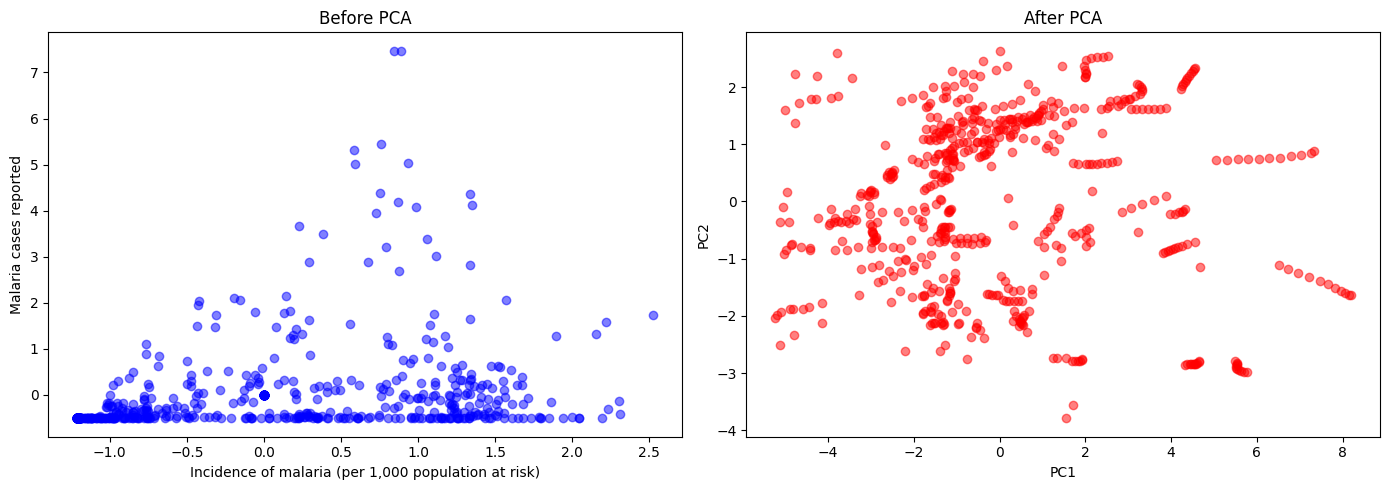

In [19]:
fig, (ax1,ax2) = plt.subplots(1,2, figsize=(14,5))

ax1.scatter ( X_standardized[:,1], X_standardized[:,2],alpha=0.5,color="blue")
ax1.set_xlabel(df.columns[1])
ax1.set_ylabel(df.columns[2])
ax1.set_title('Before PCA')

ax2.scatter(reduced_data[:,0], reduced_data[:,1], alpha=0.5,color= "red")
ax2.set_xlabel('PC1')
ax2.set_ylabel('PC2')
ax2.set_title('After PCA')

plt.tight_layout()
plt.show()

Please make sure you do not use more than 5 lines to answer each of the following points:

1. Interpret the Visual you just created of the before and after PCA.

Ans: Before PCA, malaria incidence and malaria cases reported form a dense cluster near the origin with a handful of extreme outliers stretching the axes, so most country-years look similar on these two raw features alone. After PCA, the same 594 points are spread across PC1 and PC2, the two directions of greatest combined variance across all 24 features, revealing distinct bands and clusters of countries that were indistinguishable before.

2. Explain why you selected the number of principle components, more especially explain what tradeoffs you are making

Ans: We selected the smallest number of components whose cumulative explained variance reaches 95% (`np.argmax(cumulative_variance >= 0.95) + 1` = 15 of 24 components, retaining 95.07% of variance). This favours near-complete information retention over compactness: 15 dimensions is a modest reduction from 24, but it preserves almost all of the dataset's structure, at the cost of less dramatic dimensionality reduction.

3. Clearly mention based on your use case/ dataset ("economic activity”, “population pressure”), What information is lost when reducing dimensions?

Ans: Dropping the remaining 9 components discards about 5% of total variance which are mainly small, country-specific fluctuations in indicators like population growth rates and water/sanitation access that don't align with the dominant malaria-burden and demographic axes. Two country-years with similar 15-component scores could still differ in localized infrastructure or migration patterns, detail that is compressed away in the reduced data.
